# Results

This notebook compares experiment outcomes across hyperparameter settings. It separates fixed from varied parameters, measures spread differences and parameter interactions, compares optimized municipality sets, and examines how company propagation importance changes with the model settings.

In [1]:
from __future__ import annotations

import itertools
import json
import os
import sys
from pathlib import Path

import hypernetx as hnx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "scripts/run_experiment.py").exists():
            return candidate
    raise FileNotFoundError("Could not find the project root")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
configured_results_dir = os.environ.get("INFLUENCE_RESULTS_DIR")
RESULTS_DIR = (
    Path(configured_results_dir).expanduser().resolve()
    if configured_results_dir
    else PROJECT_ROOT / "results" / "experiment"
)
RESULTS_PATH = RESULTS_DIR / "results.csv"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.gip_model import GIPParameters, aligned_edge_parameters, aligned_node_weights, gip

RESULTS_PATH

PosixPath('/Users/matteobergamaschi/Desktop/rete_ipl_git/results/experiment/results.csv')

## Load and validate

In [2]:
if not RESULTS_PATH.exists():
    raise FileNotFoundError(f"No results found at {RESULTS_PATH}")

results = pd.read_csv(RESULTS_PATH)
required_columns = {"year", "start_spread", "finish_spread", "start_list", "finish_list"}
missing_columns = required_columns - set(results.columns)
if missing_columns:
    raise ValueError(f"Missing result columns: {sorted(missing_columns)}")
for column in ["start_list", "finish_list"]:
    results[column] = results[column].map(json.loads)

start_spread_position = results.columns.get_loc("start_spread")
PARAMETER_COLUMNS = results.columns[1:start_spread_position].tolist()
INSTANCE_COLUMNS = ["year", *PARAMETER_COLUMNS]
VARYING_PARAMETERS = [column for column in PARAMETER_COLUMNS if results[column].nunique(dropna=False) > 1]
FIXED_PARAMETERS = [column for column in PARAMETER_COLUMNS if column not in VARYING_PARAMETERS]
YEARS = sorted(results["year"].astype(int).unique())

results["spread_gain"] = results["finish_spread"] - results["start_spread"]
results["spread_gain_pct"] = 100 * results["spread_gain"] / results["start_spread"]

def start_finish_metrics(row: pd.Series) -> pd.Series:
    start = set(int(value) for value in row["start_list"])
    finish = set(int(value) for value in row["finish_list"])
    return pd.Series({
        "retained_seeds": len(start & finish),
        "replaced_seeds": len(start - finish),
        "start_finish_jaccard": len(start & finish) / len(start | finish),
    })

results = pd.concat([results, results.apply(start_finish_metrics, axis=1)], axis=1)
municipalities = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "node_parameters.csv",
    usecols=["year", "municipality_id", "municipality_name"],
)
municipality_names = (
    municipalities.drop_duplicates(["year", "municipality_id"])
    .set_index(["year", "municipality_id"])["municipality_name"]
    .to_dict()
)

checks = pd.Series({
    "one row per year and full parameter instance": not results.duplicated(INSTANCE_COLUMNS).any(),
    "finite spread values": np.isfinite(results[["start_spread", "finish_spread"]]).all().all(),
    "finish spread is at least start spread": results["finish_spread"].ge(results["start_spread"]).all(),
    "start-list lengths match seed budget": results.apply(lambda row: len(row["start_list"]) == row["seed_budget"], axis=1).all(),
    "finish-list lengths match seed budget": results.apply(lambda row: len(row["finish_list"]) == row["seed_budget"], axis=1).all(),
}, name="passed")
display(checks.to_frame().style.map(lambda passed: "color: #1b7f3a" if passed else "color: #b42318"))
assert checks.all(), checks[~checks]

,passed
one row per year and full parameter instance,True
finite spread values,True
finish spread is at least start spread,True
start-list lengths match seed budget,True
finish-list lengths match seed budget,True


In [3]:
varying_values = pd.DataFrame({
    "values": [sorted(results[column].drop_duplicates().tolist()) for column in VARYING_PARAMETERS],
    "count": [results[column].nunique() for column in VARYING_PARAMETERS],
}, index=VARYING_PARAMETERS)
fixed_values = results[FIXED_PARAMETERS].iloc[0].rename("value").to_frame() if FIXED_PARAMETERS else pd.DataFrame()
expected_rows = len(YEARS) * int(np.prod([results[column].nunique() for column in VARYING_PARAMETERS]))

overview = pd.Series({
    "saved rows": len(results),
    "full-grid rows expected": expected_rows,
    "grid complete": len(results) == expected_rows,
    "years": YEARS,
    "varied hyperparameters": VARYING_PARAMETERS,
}, name="value")
display(overview.to_frame())
display(Markdown("### Varied hyperparameters — these effects can be compared"))
display(varying_values)
display(Markdown("### Fixed hyperparameters — this experiment cannot estimate their effects"))
display(fixed_values)

,value
saved rows,27
full-grid rows expected,27
grid complete,True
years,"[2010, 2017, 2023]"
varied hyperparameters,"[alpha, seed_budget]"


### Varied hyperparameters — these effects can be compared

,values,count
alpha,"[0.05, 0.1, 0.2]",3
seed_budget,"[10, 20, 40]",3


### Fixed hyperparameters — this experiment cannot estimate their effects

,value
edge_weight_beta,0.500
node_weight_beta,0.500
min_edge_size,2.000
edge_weight_mean,1.000
node_weight_mean,1.000
h0,1.000
l0,1.000
theta_l,2.000
theta_h,50.000
gamma,0.100


## Spread outcomes

Finish spread describes the model outcome under each setting. Spread gain (%) isolates how much NaDS improved its deterministic starting list under that same setting. Because alpha changes the propagation thresholds themselves, finish-spread levels across alpha values represent both a model change and a seed-selection change.

In [4]:
outcome_columns = [
    "year", "alpha", "seed_budget", "start_spread", "finish_spread",
    "spread_gain", "spread_gain_pct", "retained_seeds", "start_finish_jaccard",
]
display(results[outcome_columns].sort_values(["year", "alpha", "seed_budget"]).reset_index(drop=True))

,year,alpha,seed_budget,start_spread,finish_spread,spread_gain,spread_gain_pct,retained_seeds,start_finish_jaccard
0,2010,0.050,10,"5,550.188","8,633.354","3,083.166",55.551,0.000,0.000
1,2010,0.050,20,"7,090.762","10,874.238","3,783.476",53.358,2.000,0.053
2,2010,0.050,40,"7,649.768","13,335.551","5,685.783",74.326,12.000,0.176
3,2010,0.100,10,"14,323.136","19,986.268","5,663.132",39.538,1.000,0.053
4,2010,0.100,20,"17,193.404","25,340.435","8,147.031",47.385,1.000,0.026
5,2010,0.100,40,"18,308.029","29,418.829","11,110.800",60.688,11.000,0.159
6,2010,0.200,10,"52,568.558","63,031.914","10,463.355",19.904,1.000,0.053
7,2010,0.200,20,"58,165.573","73,476.755","15,311.182",26.323,4.000,0.111
8,2010,0.200,40,"60,581.630","84,853.416","24,271.786",40.065,11.000,0.159
9,2017,0.050,10,"6,806.874","9,170.818","2,363.944",34.729,2.000,0.111


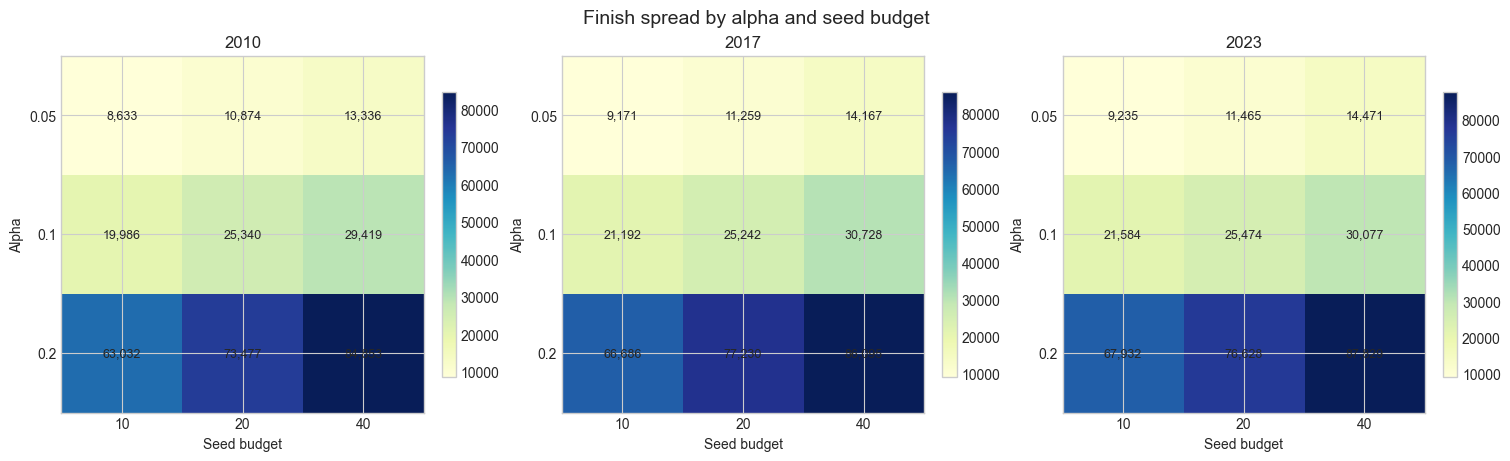

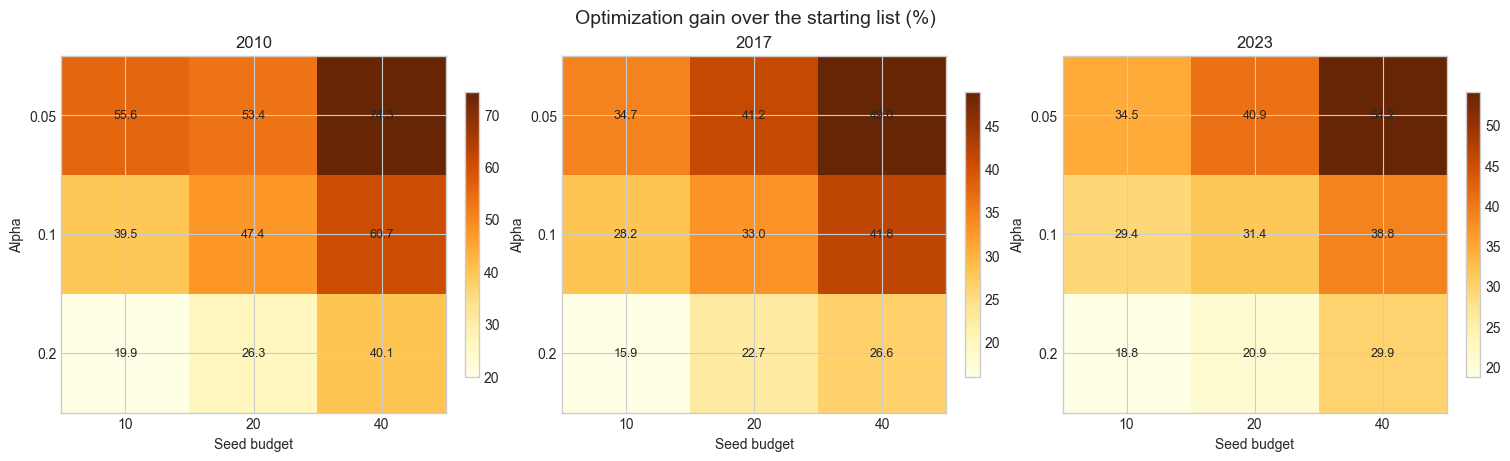

In [5]:
def parameter_heatmaps(metric: str, title: str, cmap: str, number_format: str) -> None:
    fig, axes = plt.subplots(1, len(YEARS), figsize=(5 * len(YEARS), 4.5), constrained_layout=True, squeeze=False)
    for axis, year in zip(axes.ravel(), YEARS):
        grid = (
            results.loc[results["year"].eq(year)]
            .pivot_table(index="alpha", columns="seed_budget", values=metric, aggfunc="mean")
            .sort_index().sort_index(axis=1)
        )
        image = axis.imshow(grid.to_numpy(), aspect="auto", cmap=cmap)
        axis.set_xticks(np.arange(len(grid.columns)), labels=grid.columns)
        axis.set_yticks(np.arange(len(grid.index)), labels=grid.index)
        axis.set(xlabel="Seed budget", ylabel="Alpha", title=str(year))
        for row_index in range(len(grid.index)):
            for column_index in range(len(grid.columns)):
                value = grid.iloc[row_index, column_index]
                if pd.notna(value):
                    axis.text(column_index, row_index, format(value, number_format), ha="center", va="center", fontsize=9)
        fig.colorbar(image, ax=axis, shrink=0.8)
    fig.suptitle(title, fontsize=14)
    plt.show()

parameter_heatmaps("finish_spread", "Finish spread by alpha and seed budget", "YlGnBu", ",.0f")
parameter_heatmaps("spread_gain_pct", "Optimization gain over the starting list (%)", "YlOrBr", ".1f")

## Hyperparameter effects and interactions

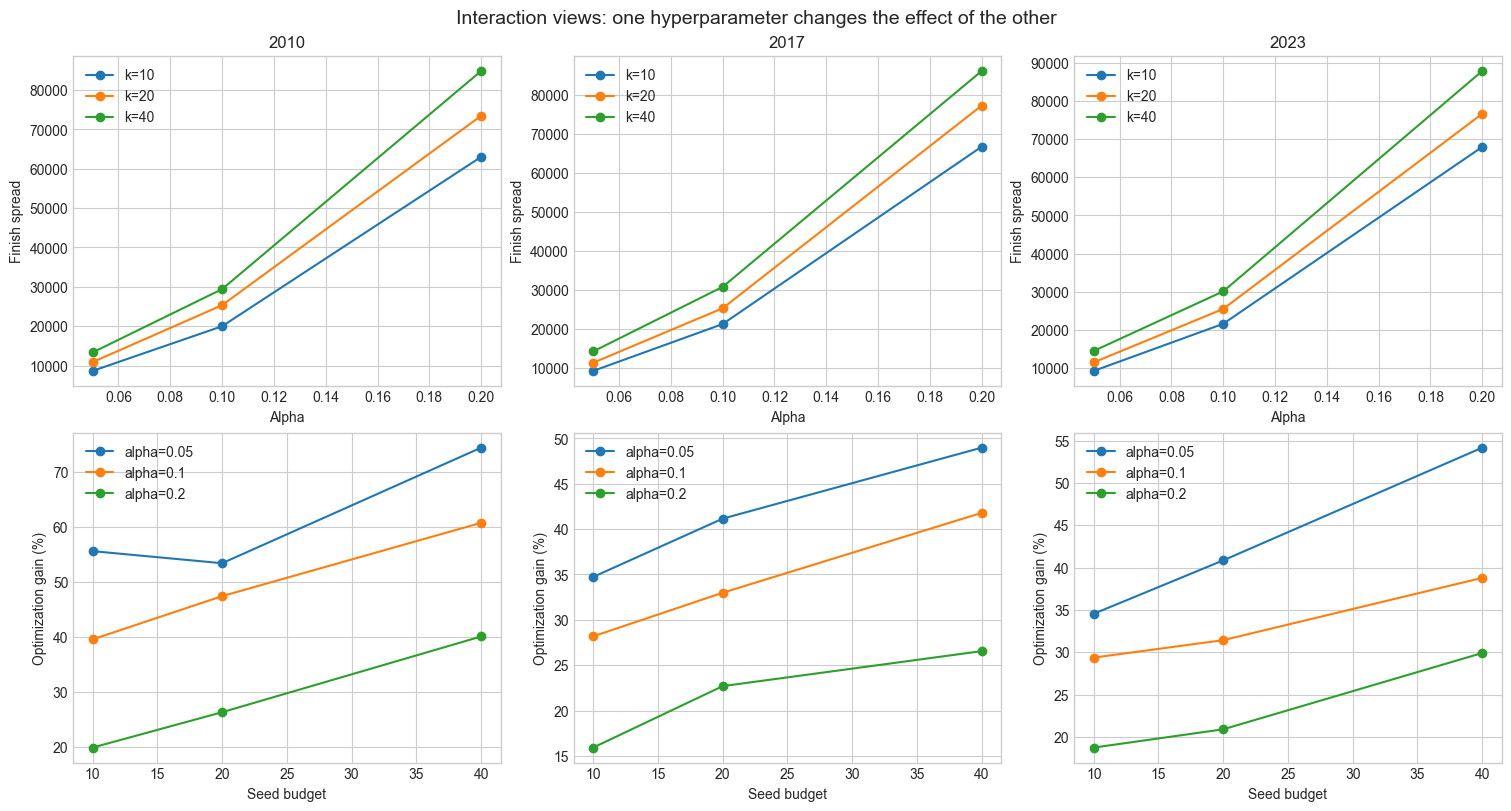

In [6]:
fig, axes = plt.subplots(2, len(YEARS), figsize=(5 * len(YEARS), 8), constrained_layout=True, squeeze=False)
for column_index, year in enumerate(YEARS):
    year_data = results.loc[results["year"].eq(year)]
    for budget, group in year_data.groupby("seed_budget"):
        group = group.sort_values("alpha")
        axes[0, column_index].plot(group["alpha"], group["finish_spread"], marker="o", label=f"k={budget}")
    for alpha, group in year_data.groupby("alpha"):
        group = group.sort_values("seed_budget")
        axes[1, column_index].plot(group["seed_budget"], group["spread_gain_pct"], marker="o", label=f"alpha={alpha:g}")
    axes[0, column_index].set(title=str(year), xlabel="Alpha", ylabel="Finish spread")
    axes[1, column_index].set(xlabel="Seed budget", ylabel="Optimization gain (%)")
    axes[0, column_index].legend()
    axes[1, column_index].legend()
fig.suptitle("Interaction views: one hyperparameter changes the effect of the other", fontsize=14)
plt.show()

In [7]:
alpha_effect_rows = []
for (year, budget), group in results.groupby(["year", "seed_budget"]):
    ordered = group.sort_values("alpha")
    low, high = ordered.iloc[0], ordered.iloc[-1]
    alpha_effect_rows.append({
        "year": year,
        "seed_budget": budget,
        "alpha_low": low["alpha"],
        "alpha_high": high["alpha"],
        "finish_spread_change": high["finish_spread"] - low["finish_spread"],
        "finish_spread_change_pct": 100 * (high["finish_spread"] / low["finish_spread"] - 1),
        "optimization_gain_change_pp": high["spread_gain_pct"] - low["spread_gain_pct"],
    })

budget_effect_rows = []
for (year, alpha), group in results.groupby(["year", "alpha"]):
    ordered = group.sort_values("seed_budget")
    low, high = ordered.iloc[0], ordered.iloc[-1]
    budget_effect_rows.append({
        "year": year,
        "alpha": alpha,
        "budget_low": int(low["seed_budget"]),
        "budget_high": int(high["seed_budget"]),
        "finish_spread_change": high["finish_spread"] - low["finish_spread"],
        "finish_spread_change_pct": 100 * (high["finish_spread"] / low["finish_spread"] - 1),
        "optimization_gain_change_pp": high["spread_gain_pct"] - low["spread_gain_pct"],
    })

display(Markdown("### Change from the lowest to highest alpha, holding year and seed budget fixed"))
display(pd.DataFrame(alpha_effect_rows))
display(Markdown("### Change from the smallest to largest seed budget, holding year and alpha fixed"))
display(pd.DataFrame(budget_effect_rows))

### Change from the lowest to highest alpha, holding year and seed budget fixed

,year,seed_budget,alpha_low,alpha_high,finish_spread_change,finish_spread_change_pct,optimization_gain_change_pp
0,2010,10,0.050,0.200,"54,398.560",630.098,-35.646
1,2010,20,0.050,0.200,"62,602.517",575.696,-27.034
2,2010,40,0.050,0.200,"71,517.865",536.295,-34.262
3,2017,10,0.050,0.200,"57,515.611",627.159,-18.805
4,2017,20,0.050,0.200,"65,970.345",585.919,-18.457
5,2017,40,0.050,0.200,"71,928.400",507.730,-22.422
6,2023,10,0.050,0.200,"58,697.064",635.582,-15.792
7,2023,20,0.050,0.200,"65,162.499",568.354,-19.940
8,2023,40,0.050,0.200,"73,357.479",506.913,-24.236


### Change from the smallest to largest seed budget, holding year and alpha fixed

,year,alpha,budget_low,budget_high,finish_spread_change,finish_spread_change_pct,optimization_gain_change_pp
0,2010,0.050,10,40,"4,702.197",54.465,18.776
1,2010,0.100,10,40,"9,432.561",47.195,21.150
2,2010,0.200,10,40,"21,821.502",34.620,20.160
3,2017,0.050,10,40,"4,995.842",54.475,14.246
4,2017,0.100,10,40,"9,536.836",45.003,13.608
5,2017,0.200,10,40,"19,408.631",29.104,10.629
6,2023,0.050,10,40,"5,236.235",56.699,19.607
7,2023,0.100,10,40,"8,492.386",39.345,9.416
8,2023,0.200,10,40,"19,896.650",29.289,11.163


## How hyperparameters change the optimized municipality set

In [8]:
pairwise_rows = []
for year, year_data in results.groupby("year"):
    for (index_a, row_a), (index_b, row_b) in itertools.combinations(year_data.iterrows(), 2):
        set_a = set(int(value) for value in row_a["finish_list"])
        set_b = set(int(value) for value in row_b["finish_list"])
        shared = set_a & set_b
        union = set_a | set_b
        changed_parameters = [
            parameter for parameter in VARYING_PARAMETERS
            if not np.isclose(float(row_a[parameter]), float(row_b[parameter]), rtol=0, atol=1e-12)
        ]
        pairwise_rows.append({
            "year": int(year),
            "result_a": int(index_a),
            "result_b": int(index_b),
            "changed_parameters": " + ".join(changed_parameters),
            "alpha_a": row_a["alpha"],
            "alpha_b": row_b["alpha"],
            "seed_budget_a": int(row_a["seed_budget"]),
            "seed_budget_b": int(row_b["seed_budget"]),
            "shared": len(shared),
            "jaccard": len(shared) / len(union),
            "smaller_set_containment": len(shared) / min(len(set_a), len(set_b)),
        })
pairwise = pd.DataFrame(pairwise_rows)
pairwise_summary = (
    pairwise.groupby("changed_parameters")
    .agg(
        comparisons=("year", "size"),
        mean_jaccard=("jaccard", "mean"),
        min_jaccard=("jaccard", "min"),
        mean_smaller_set_containment=("smaller_set_containment", "mean"),
    )
    .sort_values("mean_jaccard")
)
display(pairwise_summary)

,comparisons,mean_jaccard,min_jaccard,mean_smaller_set_containment
changed_parameters,,,,
alpha + seed_budget,54,0.196,0.064,0.567
seed_budget,27,0.197,0.087,0.565
alpha,27,0.292,0.143,0.439


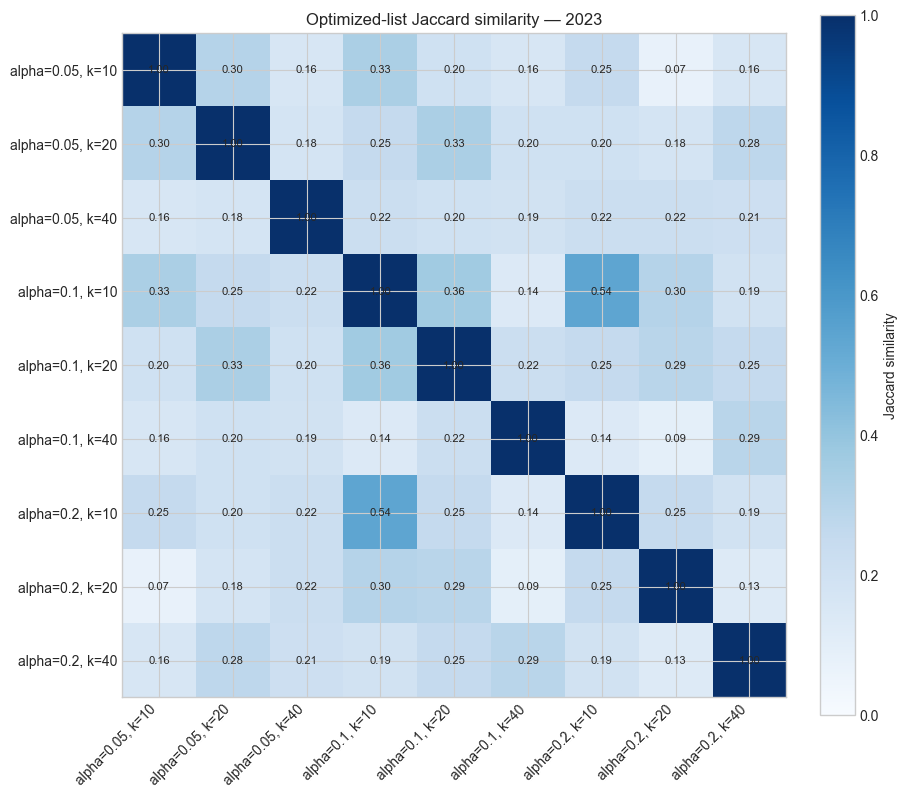

In [9]:
SELECTION_YEAR = max(YEARS)
selection_rows = results.loc[results["year"].eq(SELECTION_YEAR)].sort_values(["alpha", "seed_budget"])
selection_sets = [set(int(value) for value in values) for values in selection_rows["finish_list"]]
selection_labels = [f"alpha={row.alpha:g}, k={int(row.seed_budget)}" for row in selection_rows.itertuples()]
jaccard_matrix = np.eye(len(selection_sets))
for row_index, column_index in itertools.combinations(range(len(selection_sets)), 2):
    set_a, set_b = selection_sets[row_index], selection_sets[column_index]
    value = len(set_a & set_b) / len(set_a | set_b)
    jaccard_matrix[row_index, column_index] = value
    jaccard_matrix[column_index, row_index] = value

fig, axis = plt.subplots(figsize=(9, 8), constrained_layout=True)
image = axis.imshow(jaccard_matrix, cmap="Blues", vmin=0, vmax=1)
axis.set_xticks(np.arange(len(selection_labels)), labels=selection_labels, rotation=45, ha="right")
axis.set_yticks(np.arange(len(selection_labels)), labels=selection_labels)
axis.set_title(f"Optimized-list Jaccard similarity — {SELECTION_YEAR}")
for row_index in range(len(selection_labels)):
    for column_index in range(len(selection_labels)):
        axis.text(column_index, row_index, f"{jaccard_matrix[row_index, column_index]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=axis, label="Jaccard similarity")
plt.show()

## Municipalities robust to hyperparameter changes

,municipality_id,municipality_name,appearances,years,alpha_values,seed_budgets,mean_rank
0,1199250158,COMUNE DI MILANO,23,3,3,3,1.130
1,145920351,COMUNE DI REGGIO NELL'EMILIA,23,3,3,3,2.043
2,80034840167,COMUNE DI BERGAMO,20,3,3,3,6.400
3,215150236,COMUNE DI VERONA,18,3,3,3,3.333
4,147990923,COMUNE DI CAGLIARI,17,3,3,3,19.471
5,644060287,COMUNE DI PADOVA,16,3,3,3,4.375
6,137020871,COMUNE DI CATANIA,16,3,3,3,21.500
7,514490010,COMUNE DI TORINO,14,3,3,3,6.286
8,2253930156,COMUNE DI SESTO SAN GIOVANNI,14,3,3,3,9.786
9,168650307,COMUNE DI UDINE,12,3,3,3,7.000


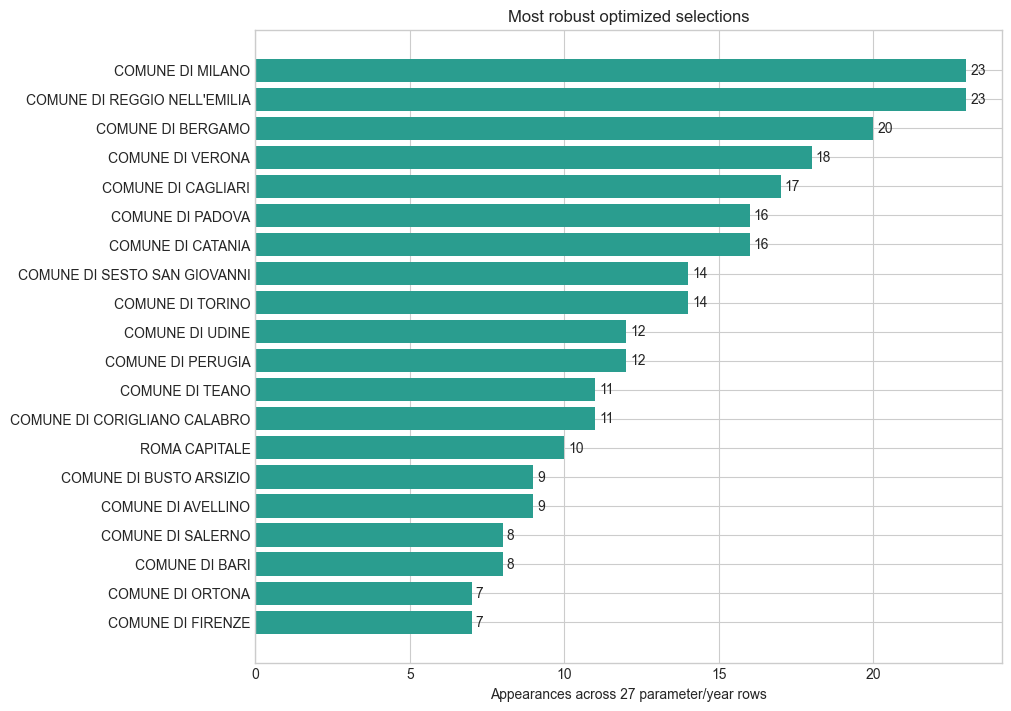

In [10]:
selection_entries = []
for result_index, row in results.iterrows():
    for rank, municipality_id in enumerate(row["finish_list"], start=1):
        municipality_id = int(municipality_id)
        selection_entries.append({
            "result_index": int(result_index),
            "year": int(row["year"]),
            "alpha": row["alpha"],
            "seed_budget": int(row["seed_budget"]),
            "municipality_id": municipality_id,
            "municipality_name": municipality_names.get((int(row["year"]), municipality_id), "unknown"),
            "rank": rank,
        })
selections = pd.DataFrame(selection_entries)
municipality_summary = (
    selections.groupby(["municipality_id", "municipality_name"])
    .agg(
        appearances=("result_index", "size"),
        years=("year", "nunique"),
        alpha_values=("alpha", "nunique"),
        seed_budgets=("seed_budget", "nunique"),
        mean_rank=("rank", "mean"),
    )
    .reset_index()
    .sort_values(["appearances", "years", "mean_rank"], ascending=[False, False, True])
)
display(municipality_summary.head(25).reset_index(drop=True))

plot_data = municipality_summary.head(20).sort_values("appearances")
fig, axis = plt.subplots(figsize=(10, 7), constrained_layout=True)
axis.barh(plot_data["municipality_name"], plot_data["appearances"], color="#2a9d8f")
axis.set(title="Most robust optimized selections", xlabel=f"Appearances across {len(results)} parameter/year rows")
axis.bar_label(axis.containers[0], padding=3)
plt.show()

## Inspect one parameter setting

In [11]:
INSPECT_YEAR = max(YEARS)
INSPECT_ALPHA = 0.10
INSPECT_SEED_BUDGET = 20

inspect_matches = results.loc[
    results["year"].eq(INSPECT_YEAR)
    & np.isclose(results["alpha"], INSPECT_ALPHA)
    & results["seed_budget"].eq(INSPECT_SEED_BUDGET)
]
if inspect_matches.empty:
    chosen_result = results.sort_values(["year", "alpha", "seed_budget"]).iloc[-1]
    INSPECT_YEAR = int(chosen_result["year"])
    INSPECT_ALPHA = float(chosen_result["alpha"])
    INSPECT_SEED_BUDGET = int(chosen_result["seed_budget"])
    display(Markdown("Preferred setting was not saved yet; using the latest available row."))
elif len(inspect_matches) > 1:
    raise ValueError("More than one row matches; filter another varied parameter as well")
else:
    chosen_result = inspect_matches.iloc[0]

CHOSEN_RESULT_INDEX = int(chosen_result.name)
start_ids = [int(value) for value in chosen_result["start_list"]]
finish_ids = [int(value) for value in chosen_result["finish_list"]]
start_set, finish_set = set(start_ids), set(finish_ids)
start_table = pd.DataFrame({
    "start_rank": range(1, len(start_ids) + 1),
    "municipality_id": start_ids,
    "municipality_name": [municipality_names.get((INSPECT_YEAR, value), "unknown") for value in start_ids],
    "status": ["retained" if value in finish_set else "removed" for value in start_ids],
})
finish_table = pd.DataFrame({
    "finish_rank": range(1, len(finish_ids) + 1),
    "municipality_id": finish_ids,
    "municipality_name": [municipality_names.get((INSPECT_YEAR, value), "unknown") for value in finish_ids],
    "status": ["retained" if value in start_set else "added" for value in finish_ids],
})
display(Markdown(f"### year={INSPECT_YEAR}, alpha={INSPECT_ALPHA:g}, seed_budget={INSPECT_SEED_BUDGET}"))
display(chosen_result[["start_spread", "finish_spread", "spread_gain_pct", "retained_seeds", "start_finish_jaccard"]].rename("value").to_frame())
display(Markdown("### Starting list"), start_table, Markdown("### Optimized list"), finish_table)

### year=2023, alpha=0.1, seed_budget=20

,value
start_spread,"19,381.411"
finish_spread,"25,474.148"
spread_gain_pct,31.436
retained_seeds,6.000
start_finish_jaccard,0.176


### Starting list

,start_rank,municipality_id,municipality_name,status
0,1,168650307,COMUNE DI UDINE,retained
1,2,516890241,COMUNE DI VICENZA,removed
2,3,761890177,COMUNE DI BRESCIA,removed
3,4,2253930156,COMUNE DI SESTO SAN GIOVANNI,retained
4,5,524950177,COMUNE DI CALCINATO,retained
5,6,145920351,COMUNE DI REGGIO NELL'EMILIA,retained
6,7,645400177,COMUNE DI MONTICHIARI,removed
7,8,80004590677,COMUNE DI CROGNALETO,removed
8,9,159200674,COMUNE DI PINETO,removed
9,10,644060287,COMUNE DI PADOVA,removed


### Optimized list

,finish_rank,municipality_id,municipality_name,status
0,1,1199250158,COMUNE DI MILANO,retained
1,2,145920351,COMUNE DI REGGIO NELL'EMILIA,retained
2,3,215150236,COMUNE DI VERONA,added
3,4,2438750586,ROMA CAPITALE,added
4,5,168650307,COMUNE DI UDINE,retained
5,6,514490010,COMUNE DI TORINO,added
6,7,80034840167,COMUNE DI BERGAMO,added
7,8,441780483,COMUNE DI CASTELFIORENTINO,retained
8,9,2253930156,COMUNE DI SESTO SAN GIOVANNI,retained
9,10,80005990611,COMUNE DI TEANO,added


## Companies most involved in propagation

For every saved result, this section reconstructs propagation from its optimized municipality list. Company activity is cumulative transmitted pressure multiplied by ownership-incidence strength. The final ablation comparison removes candidate companies one at a time and measures lost spread across alpha settings at a fixed year and seed budget.

In [12]:
MODEL_CACHE = {}
PROPAGATION_CACHE = {}

def model_for_row(row: pd.Series) -> dict[str, object]:
    key = (
        int(row["year"]), int(row["min_edge_size"]),
        float(row["edge_weight_mean"]), float(row["edge_weight_beta"]),
        float(row["node_weight_mean"]), float(row["node_weight_beta"]),
    )
    if key in MODEL_CACHE:
        return MODEL_CACHE[key]

    year = int(row["year"])
    incidences = pd.read_csv(PROJECT_ROOT / "data" / "processed" / f"rete_{year}.csv")
    edge_sizes = incidences.groupby("CF Partecipata")["CF Comune"].nunique()
    valid_edges = edge_sizes.loc[edge_sizes.ge(int(row["min_edge_size"]))].index
    filtered = incidences.loc[incidences["CF Partecipata"].isin(valid_edges)].copy()
    hypergraph = hnx.Hypergraph(filtered, edge_col="CF Partecipata", node_col="CF Comune", cell_weight_col="Quota")
    incidence_matrix, matrix_node_ids, matrix_edge_ids = hypergraph.incidence_matrix(index=True, weights="weight")
    node_ids = np.asarray(matrix_node_ids, dtype="int64")
    edge_weights, edge_audit = aligned_edge_parameters(
        matrix_edge_ids, year,
        PROJECT_ROOT / "data" / "processed" / "hyperedge_parameters.csv",
        target_mean=float(row["edge_weight_mean"]), beta=float(row["edge_weight_beta"]),
    )
    node_weights, _ = aligned_node_weights(
        matrix_node_ids, year,
        PROJECT_ROOT / "data" / "processed" / "node_parameters.csv",
        target_mean=float(row["node_weight_mean"]), beta=float(row["node_weight_beta"]),
    )
    model = {
        "incidence": incidence_matrix,
        "node_ids": node_ids,
        "edge_weights": edge_weights,
        "node_weights": node_weights,
        "edge_audit": edge_audit,
        "incidence_strength": np.asarray(incidence_matrix.sum(axis=0)).reshape(-1),
    }
    MODEL_CACHE[key] = model
    return model

def propagation_for_row(result_index: int, row: pd.Series) -> dict[str, object]:
    if result_index in PROPAGATION_CACHE:
        return PROPAGATION_CACHE[result_index]
    model = model_for_row(row)
    seed_ids = set(int(value) for value in row["finish_list"])
    seed_state = np.isin(model["node_ids"], list(seed_ids)).astype(float) * float(row["seed_intensity"])
    parameters = GIPParameters(
        h0=float(row["h0"]), l0=float(row["l0"]),
        theta_l=float(row["theta_l"]), theta_h=float(row["theta_h"]),
        gamma=float(row["gamma"]), eps=float(row["eps"]),
    )
    propagation = gip(
        model["incidence"], model["edge_weights"], seed_state, parameters,
        node_weights=model["node_weights"], stress_level=float(row["stress_level"]), alpha=float(row["alpha"]),
    )
    transmitted = np.zeros(model["incidence"].shape[1])
    active_steps = np.zeros(model["incidence"].shape[1], dtype=int)
    for state in propagation.states[:-1]:
        pressure = np.asarray(model["incidence"].T @ state).reshape(-1)
        active = pressure > float(row["stress_level"])
        transmitted += pressure * active * model["edge_weights"]
        active_steps += active.astype(int)
    activity = transmitted * model["incidence_strength"]
    metrics = model["edge_audit"].reset_index().copy()
    metrics["activity"] = activity
    metrics["activity_share_pct"] = 100 * activity / activity.sum() if activity.sum() else 0.0
    metrics["activity_rank"] = metrics["activity"].rank(method="min", ascending=False)
    metrics["active_steps"] = active_steps
    output = {"model": model, "seed_state": seed_state, "propagation": propagation, "metrics": metrics, "parameters": parameters}
    PROPAGATION_CACHE[result_index] = output
    return output

In [13]:
activity_frames = []
reconstruction_checks = []
for result_index, row in results.iterrows():
    reconstructed = propagation_for_row(int(result_index), row)
    metrics = reconstructed["metrics"].copy()
    metrics["result_index"] = int(result_index)
    metrics["year"] = int(row["year"])
    metrics["alpha"] = float(row["alpha"])
    metrics["seed_budget"] = int(row["seed_budget"])
    activity_frames.append(metrics)
    reconstruction_checks.append({
        "result_index": int(result_index),
        "saved_finish_spread": row["finish_spread"],
        "reconstructed_finish_spread": reconstructed["propagation"].total_spread,
        "absolute_difference": abs(row["finish_spread"] - reconstructed["propagation"].total_spread),
    })
company_activity = pd.concat(activity_frames, ignore_index=True)
reconstruction_checks = pd.DataFrame(reconstruction_checks)
assert reconstruction_checks["absolute_difference"].max() < 1e-6

company_summary = (
    company_activity.groupby(["company_id", "company_name"])
    .agg(
        runs_present=("result_index", "nunique"),
        top_20_appearances=("activity_rank", lambda values: int(values.le(20).sum())),
        mean_activity_rank=("activity_rank", "mean"),
        mean_activity_share_pct=("activity_share_pct", "mean"),
        max_activity_share_pct=("activity_share_pct", "max"),
    )
    .reset_index()
    .sort_values(["top_20_appearances", "mean_activity_rank"], ascending=[False, True])
)
display(Markdown("### Companies consistently active across hyperparameter settings"))
display(company_summary.head(20).reset_index(drop=True))

### Companies consistently active across hyperparameter settings

,company_id,company_name,runs_present,top_20_appearances,mean_activity_rank,mean_activity_share_pct,max_activity_share_pct
0,1429910183,A.S.M. VOGHERA S.P.A.,27,23,13.593,0.163,0.200
1,3178060236,V-RETI S.P.A.,27,19,12.630,0.175,0.249
2,2730490238,SER.I.T. S.R.L.,27,18,27.556,0.165,0.232
3,3567090232,ACQUE VERONESI S.C.A R.L.,27,17,199.519,0.139,0.233
4,2212870121,AGESP S.P.A.,27,16,18.296,0.166,0.265
5,1747910188,A.S.M. PAVIA S.P.A.,27,16,18.556,0.159,0.192
6,3860240286,APS HOLDING S.P.A.,18,14,8.833,0.172,0.233
7,4855090488,QUADRIFOGLIO SERVIZI AMBIENTALI AREA FIORENTINA SPA,27,14,119.185,0.143,0.227
8,516350972,A.S.M. - AMBIENTE/SERVIZI/MOBILITA' S.P.A.,18,13,18.444,0.159,0.225
9,94015790309,NET - S.P.A.,27,13,59.889,0.153,0.206


### Company propagation share across alpha — year=2023, seed_budget=20

alpha,0.050,0.100,0.200
company_name,,,
AGESP S.P.A.,0.231,0.167,0.162
AGESP ENERGIA S.R.L.,0.226,0.163,0.158
V-RETI S.P.A.,0.217,0.191,0.175
AZIENDA GENERALE SERVIZI MUNICIPALI DI VERONA S.P.A - IN FORMA ABBREVIATA AGSM VERONA S.P.A.,0.217,0.191,0.175
AGESP ATTIVITA' STRUMENTALI S.R.L.,0.215,0.155,0.150
ENERGIA E INFRASTRUTTURE ESCO S.R.L. IN SIGLA EN.IN. ESCO S.R.L.,0.211,0.186,0.170
"AZIENDA MULTISERVIZI DI IGIENE AMBIENTALE DI VERONA S.P.A. ABBREVIATA IN ""AMIA VERONA S.P.A.""",0.210,0.185,0.170
AGSM AIM CALORE S.R.L.,0.209,0.184,0.169
AGSM LIGHTING S.R.L.,0.207,0.182,0.167


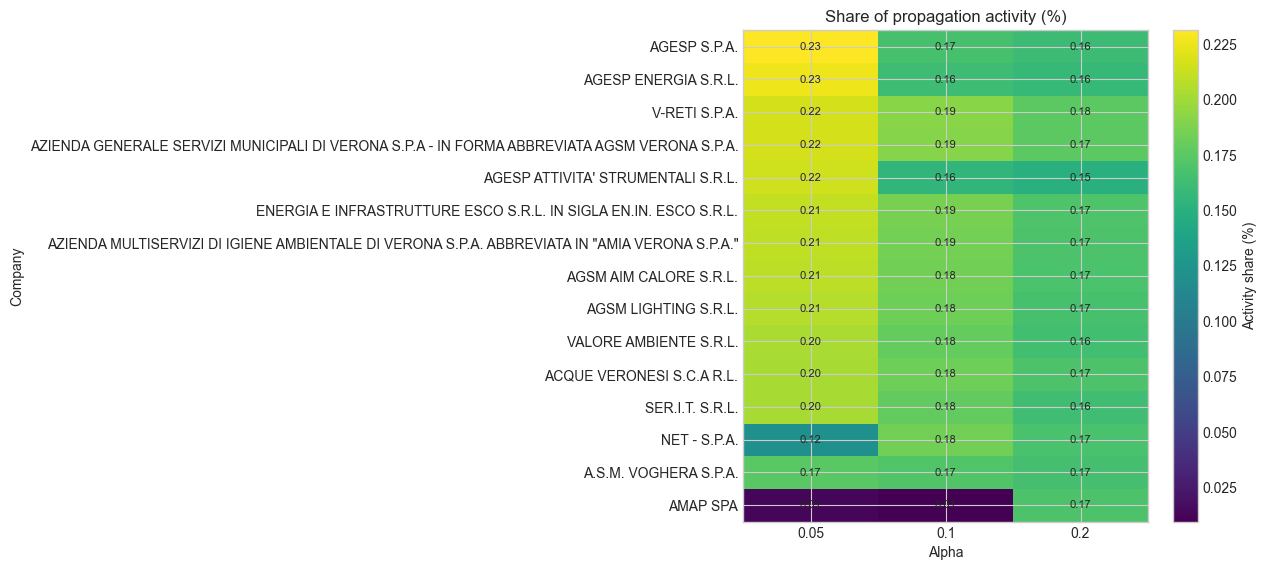

In [14]:
COMPANY_YEAR = max(YEARS)
COMPANY_SEED_BUDGET = 20
company_comparison = company_activity.loc[
    company_activity["year"].eq(COMPANY_YEAR)
    & company_activity["seed_budget"].eq(COMPANY_SEED_BUDGET)
].copy()
top_company_ids = set(
    company_comparison.sort_values("activity_rank").groupby("alpha").head(10)["company_id"]
)
activity_pivot = (
    company_comparison.loc[company_comparison["company_id"].isin(top_company_ids)]
    .pivot_table(index="company_name", columns="alpha", values="activity_share_pct", aggfunc="mean")
)
activity_pivot = activity_pivot.loc[activity_pivot.max(axis=1).sort_values(ascending=False).index]
display(Markdown(f"### Company propagation share across alpha — year={COMPANY_YEAR}, seed_budget={COMPANY_SEED_BUDGET}"))
display(activity_pivot)

fig, axis = plt.subplots(figsize=(11, max(6, 0.42 * len(activity_pivot))))
image = axis.imshow(activity_pivot.to_numpy(), aspect="auto", cmap="viridis")
axis.set_xticks(np.arange(len(activity_pivot.columns)), labels=activity_pivot.columns)
axis.set_yticks(np.arange(len(activity_pivot.index)), labels=activity_pivot.index)
axis.set(xlabel="Alpha", ylabel="Company", title="Share of propagation activity (%)")
for row_index in range(len(activity_pivot.index)):
    for column_index in range(len(activity_pivot.columns)):
        axis.text(column_index, row_index, f"{activity_pivot.iloc[row_index, column_index]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=axis, label="Activity share (%)")
fig.subplots_adjust(left=0.42, right=0.88, bottom=0.12, top=0.90)
plt.show()

### Company ablation across alpha

Ablation spread loss is the model spread removed when one company transmission weight is set to zero. It is conditional on each alpha-specific optimized municipality list and is not a causal estimate.

alpha,0.050,0.100,0.200
company_name,,,
"ALTO TREVIGIANO SERVIZI SRL IN SIGLA ""A.T.S. S.R.L.""",0.000,0.295,0.000
ACQUE VERONESI S.C.A R.L.,0.232,0.281,0.210
COSMARI SRL - SOCIETA' A RESPONSABILITA' LIMITATA,0.017,0.278,0.040
ENERGIA TERRITORIO RISORSE AMBIENTALI - ETRA S.P.A.,0.000,0.000,0.109
SOCIETA' LOCALE DI RISCOSSIONE S.P.A. IN SIGLA SO.LO.RI. S.P.A.,0.050,0.053,0.037
NET - S.P.A.,0.003,0.044,0.047
AMAP SPA,0.019,0.005,0.000
AGESP S.P.A.,0.001,0.000,0.000
AGESP ENERGIA S.R.L.,0.001,0.000,0.000


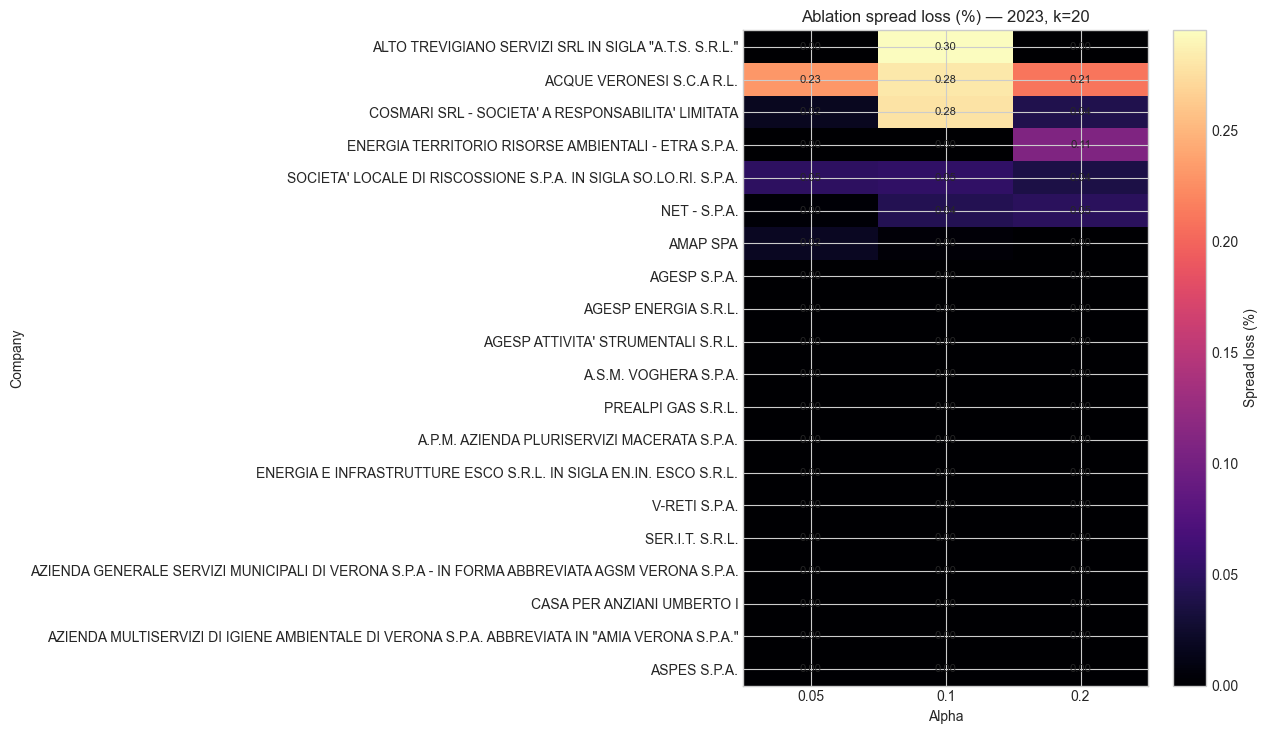

In [15]:
ABLATION_CANDIDATES_PER_ALPHA = 15
comparison_result_rows = results.loc[
    results["year"].eq(COMPANY_YEAR)
    & results["seed_budget"].eq(COMPANY_SEED_BUDGET)
].sort_values("alpha")
candidate_company_ids = set()
for result_index, row in comparison_result_rows.iterrows():
    metrics = propagation_for_row(int(result_index), row)["metrics"]
    candidate_company_ids.update(metrics.nlargest(ABLATION_CANDIDATES_PER_ALPHA, "activity")["company_id"].tolist())

ablation_rows = []
for result_index, row in comparison_result_rows.iterrows():
    reconstructed = propagation_for_row(int(result_index), row)
    model = reconstructed["model"]
    baseline_spread = reconstructed["propagation"].total_spread
    metrics = reconstructed["metrics"]
    company_to_edge = metrics.reset_index().set_index("company_id")["index"].to_dict()
    for company_id in sorted(candidate_company_ids):
        if company_id not in company_to_edge:
            continue
        edge_index = int(company_to_edge[company_id])
        ablated_weights = model["edge_weights"].copy()
        ablated_weights[edge_index] = 0.0
        ablated = gip(
            model["incidence"], ablated_weights, reconstructed["seed_state"], reconstructed["parameters"],
            node_weights=model["node_weights"], stress_level=float(row["stress_level"]), alpha=float(row["alpha"]),
        )
        company_row = metrics.iloc[edge_index]
        loss = baseline_spread - ablated.total_spread
        ablation_rows.append({
            "alpha": float(row["alpha"]),
            "company_id": company_id,
            "company_name": company_row["company_name"],
            "ablation_spread_loss": loss,
            "ablation_spread_loss_pct": 100 * loss / baseline_spread,
        })
company_ablation = pd.DataFrame(ablation_rows)
ablation_pivot = company_ablation.pivot_table(
    index="company_name", columns="alpha", values="ablation_spread_loss_pct", aggfunc="mean"
)
ablation_pivot = ablation_pivot.loc[ablation_pivot.max(axis=1).sort_values(ascending=False).head(20).index]
display(ablation_pivot)

fig, axis = plt.subplots(figsize=(11, max(6, 0.42 * len(ablation_pivot))))
image = axis.imshow(ablation_pivot.to_numpy(), aspect="auto", cmap="magma")
axis.set_xticks(np.arange(len(ablation_pivot.columns)), labels=ablation_pivot.columns)
axis.set_yticks(np.arange(len(ablation_pivot.index)), labels=ablation_pivot.index)
axis.set(xlabel="Alpha", ylabel="Company", title=f"Ablation spread loss (%) — {COMPANY_YEAR}, k={COMPANY_SEED_BUDGET}")
for row_index in range(len(ablation_pivot.index)):
    for column_index in range(len(ablation_pivot.columns)):
        value = ablation_pivot.iloc[row_index, column_index]
        if pd.notna(value):
            axis.text(column_index, row_index, f"{value:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=axis, label="Spread loss (%)")
fig.subplots_adjust(left=0.42, right=0.88, bottom=0.12, top=0.90)
plt.show()

## Interpretation guide

- Use spread gain (%) to compare optimization effectiveness within a model setting.
- Use finish spread to describe the outcome produced by a setting, remembering that alpha changes the propagation model itself.
- Low Jaccard similarity means the optimized municipality recommendation is sensitive to the changed hyperparameter.
- Smaller-set containment is more informative than Jaccard when comparing different seed budgets.
- Company activity and ablation rankings are conditional on the model parameters and selected seed list; they are descriptive model outputs, not causal effects.